In [1]:
#uncomment and run this if need be
#!pip install -r ../requirements.txt

In [2]:
from pathlib import Path
import torch
from typing import Dict, List, Tuple
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from collections import OrderedDict
import re
import random
import torch.nn as nn
import torch.optim as optim
import hashlib
import pandas as pd
import torch.nn.functional as F
import math
import itertools
import collections
from IPython.display import display
import os, time, json
import matplotlib.pyplot as plt
import numpy as np

In [3]:


BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
CKPT_DIR = BASE_DIR / "checkpoints"
DUMMY_DIR = DATA_DIR / "Dummy"
PGC_DIR = DATA_DIR / "Partial_Guessing_Curves"

# checkpoints
PRETRAIN_CKPT_PATH = CKPT_DIR / "tg_pretrain_20251127_022343.pt"
PRE_RL_CKPT_PATH   = CKPT_DIR / "clean_LTR_20250827_183414.pt"
POST_C4_CKPT_PATH  = CKPT_DIR / "postC4_20250828_204049.pt"
RL1_CKPT_PATH      = CKPT_DIR / "postRL1_20251127_032203.pt"

# data
PII_DICT_PATH   = DUMMY_DIR / "dummy_dataset_pii_tag.json"
SWEETWORDS_PATH = DUMMY_DIR / "Sweetwords_Chunks1.json"
EXTRACTED_PATH  = DUMMY_DIR / "extracted_chunks_tags.json"

os.makedirs(PGC_DIR, exist_ok=True)

print("Paths initialized.")

Paths initialized.


In [4]:
# S0+S1 — load + align data

# ---- load raw JSONs ----
with open(PII_DICT_PATH, "r") as f:
    users_pii_tag_dictionaries_raw = json.load(f)["users_pii_tag_dictionaries"]

with open(SWEETWORDS_PATH, "r") as f:
    sweetwords_dictionaries_raw = json.load(f)

# ---- normalize user IDs so keys match across files ----
def norm_uid(u: str) -> str:
    s = str(u).strip()
    m = re.match(r'(?i)user\s*0*([0-9]+)$', s)
    return f"User{m.group(1)}" if m else s

pii_norm = {norm_uid(u): v for u, v in users_pii_tag_dictionaries_raw.items()}
sw_norm  = {norm_uid(u): v for u, v in sweetwords_dictionaries_raw.items()}

common_users = sorted(set(pii_norm) & set(sw_norm))
assert common_users, "No overlapping users found between PII and sweetwords."

# ---- align users ----
ALIGNED = {}
for u in common_users:
    sw = sw_norm[u]
    assert isinstance(sw, dict) and len(sw) >= 1, f"Bad sweetwords for {u}"
    ALIGNED[u] = {
        "pii": pii_norm[u],
        "sweetwords": sw
    }

assert len(ALIGNED) > 0, "No aligned users after filtering."

# ---- canonical working variables used later ----
users_pii_tag_dictionaries = {u: ALIGNED[u]["pii"] for u in ALIGNED}
sweetwords_dictionaries    = {u: ALIGNED[u]["sweetwords"] for u in ALIGNED}

print(f"Aligned users loaded: {len(ALIGNED)}")

Aligned users loaded: 4


In [5]:
# clean + standardize data for the model



SPECIAL_TAGS = {"special_char", "separator", "sep", "symbol"}

def _norm_str(s: str) -> str:
    return re.sub(r"\s+", " ", str(s)).strip().lower()

def canonicalize_user_pii(user_pii_dict):
    """
    Input:  {raw_value: raw_tag, ...}
    Output: ordered, de-duplicated list of (tag, value) pairs
      - drop SPECIAL_TAGS
      - numbers: 1900–2099 -> 'year'; 0–99 -> 'favorite_number'
    """
    pairs = []
    for raw_val, raw_tag in user_pii_dict.items():
        t = _norm_str(raw_tag)
        v = _norm_str(raw_val)

        if t in SPECIAL_TAGS or not v:
            continue

        if v.isdigit():
            n = int(v)
            if 1900 <= n <= 2099:
                t = "year"
            elif 0 <= n <= 99:
                t = "favorite_number"

        pairs.append((t, v))

    seen, out = set(), []
    for tv in pairs:
        if tv not in seen:
            seen.add(tv)
            out.append(tv)
    return out

canonical_pii = {
    u: canonicalize_user_pii(users_pii_tag_dictionaries[u])
    for u in sorted(users_pii_tag_dictionaries)
}

assert all(len(v) >= 1 for v in canonical_pii.values()), "Some users have empty canonical PII."
print("Canonical PII built for", len(canonical_pii), "users")

Canonical PII built for 4 users


In [6]:
# S4 — Build vocabularies from canonical PII



tags, chunks = set(), set()

for pairs in canonical_pii.values():
    for t, v in pairs:
        tags.add(t)
        chunks.add(v)

# --- tag vocab ---
tag_to_id = OrderedDict()
tag_to_id["<PAD>"] = 0
tag_to_id["<UNK>"] = 1

for t in sorted(tags):
    if t in {"<pad>", "<unk>"}:
        continue
    tag_to_id[t] = len(tag_to_id)

# --- chunk vocab ---
chunk_to_id = OrderedDict()
chunk_to_id["<PAD>"] = 0
chunk_to_id["<UNK>"] = 1

for v in sorted(chunks):
    if v in {"<pad>", "<unk>"}:
        continue
    chunk_to_id[v] = len(chunk_to_id)

print("Built vocabs → tags:", len(tag_to_id), " chunks:", len(chunk_to_id))

Built vocabs → tags: 11  chunks: 38


In [7]:
# S5 — Encode PII sequences and pad to fixed length



MAX_PII_LEN = 32  # fixed length used in final experiments

def encode_user_pii_ids(user_id: str) -> List[Tuple[int, int]]:
    seq = []
    for t, v in canonical_pii[user_id]:
        tid = tag_to_id.get(t, tag_to_id["<UNK>"])
        cid = chunk_to_id.get(v, chunk_to_id["<UNK>"])
        seq.append((tid, cid))

    seq = seq[:MAX_PII_LEN]
    pad_pair = (tag_to_id["<PAD>"], chunk_to_id["<PAD>"])
    seq += [pad_pair] * (MAX_PII_LEN - len(seq))
    return seq

users_sorted = sorted(canonical_pii.keys())
user_pii_ids: Dict[str, List[Tuple[int, int]]] = {
    u: encode_user_pii_ids(u) for u in users_sorted
}

tag_seqs   = [[tid for tid, _ in user_pii_ids[u]] for u in users_sorted]
chunk_seqs = [[cid for _, cid in user_pii_ids[u]] for u in users_sorted]

X_tag = torch.tensor(tag_seqs, dtype=torch.long)
X_chk = torch.tensor(chunk_seqs, dtype=torch.long)

assert X_tag.shape == X_chk.shape
assert X_tag.shape[1] == MAX_PII_LEN

print("Encoded PII tensors:", X_tag.shape)

Encoded PII tensors: torch.Size([4, 32])


In [8]:
# S6 — Build password token vocabulary from all sweetword strings

char_counter = Counter()
for u, d in sweetwords_dictionaries.items():
    for pw in d.keys():
        char_counter.update(list(pw))

token_to_id = {"<PAD>": 0, "<UNK>": 1}
for ch in sorted(char_counter.keys()):
    if ch not in token_to_id:
        token_to_id[ch] = len(token_to_id)

token_to_id["<SOS>"] = len(token_to_id)
token_to_id["<EOS>"] = len(token_to_id)

id_to_token = {v: k for k, v in token_to_id.items()}

assert "<PAD>" in token_to_id and "<UNK>" in token_to_id
assert "<SOS>" in token_to_id and "<EOS>" in token_to_id

print("Password token vocab size:", len(token_to_id))

Password token vocab size: 54


In [9]:
# S7 — Tokenize passwords and build aligned padded tensors

PAD = token_to_id["<PAD>"]
SOS = token_to_id["<SOS>"]
EOS = token_to_id["<EOS>"]
UNK = token_to_id["<UNK>"]

def encode_password_tokens(pw: str):
    return [SOS] + [token_to_id.get(c, UNK) for c in pw] + [EOS]

def make_input_target(ids):
    return ids[:-1], ids[1:]

users_sorted = sorted(sweetwords_dictionaries.keys())
user_row = {u: i for i, u in enumerate(users_sorted)}

pw_inputs, pw_targets = [], []
users_flat, pw_strings = [], []
pii_tag_rows, pii_chk_rows = [], []

for u in users_sorted:
    for pw in sweetwords_dictionaries[u].keys():
        ids = encode_password_tokens(pw)
        x, y = make_input_target(ids)

        pw_inputs.append(torch.tensor(x, dtype=torch.long))
        pw_targets.append(torch.tensor(y, dtype=torch.long))
        users_flat.append(u)
        pw_strings.append(pw)

        r = user_row[u]
        pii_tag_rows.append(X_tag[r].tolist())
        pii_chk_rows.append(X_chk[r].tolist())

padded_input_seqs  = pad_sequence(pw_inputs, batch_first=True, padding_value=PAD)
padded_target_seqs = pad_sequence(pw_targets, batch_first=True, padding_value=PAD)

T_tag = torch.tensor(pii_tag_rows, dtype=torch.long)
T_chk = torch.tensor(pii_chk_rows, dtype=torch.long)

assert len(pw_strings) == padded_input_seqs.size(0) == padded_target_seqs.size(0)
assert T_tag.size(0) == T_chk.size(0) == len(pw_strings)
assert T_tag.size(1) == X_tag.size(1)
assert T_chk.size(1) == X_chk.size(1)

print("N samples:", len(pw_strings))
print("Input shape:", tuple(padded_input_seqs.shape))
print("Target shape:", tuple(padded_target_seqs.shape))
print("PII shape:", tuple(T_tag.shape), tuple(T_chk.shape))

N samples: 80
Input shape: (80, 16)
Target shape: (80, 16)
PII shape: (80, 32) (80, 32)


In [10]:
# S8 — Fixed train/eval split by user and fixed random real labels for evaluation

RNG = random.Random(42)

# fixed 80/20 user split used in final experiments
U = users_sorted[:]
RNG.shuffle(U)
k = int(0.8 * len(U))

train_users = sorted(U[:k])
eval_users  = sorted(U[k:])

# map each user to the indices of their samples in the flattened arrays
user_to_indices = {}
for i, u in enumerate(users_flat):
    user_to_indices.setdefault(u, []).append(i)

# fixed random real-password assignment per user (used for evaluation)
real_passwords = {}
real_pos_idx = {}

for u in users_sorted:
    pw_list = list(sweetwords_dictionaries[u].keys())
    real = RNG.choice(pw_list)
    real_passwords[u] = real
    real_pos_idx[u] = pw_list.index(real)

SAVE_DIR = DATA_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

with open(SAVE_DIR / "train_users.json", "w") as f:
    json.dump(train_users, f, indent=2)

with open(SAVE_DIR / "eval_users.json", "w") as f:
    json.dump(eval_users, f, indent=2)

with open(SAVE_DIR / "real_passwords.json", "w") as f:
    json.dump(real_passwords, f, indent=2)

with open(SAVE_DIR / "real_pos_idx.json", "w") as f:
    json.dump(real_pos_idx, f, indent=2)

print("Train users:", len(train_users), "| Eval users:", len(eval_users))
print("Fixed split and evaluation labels saved.")

Train users: 3 | Eval users: 1
Fixed split and evaluation labels saved.


In [11]:
# S9a — Model definitions (required for restore)

class PIIEncoder(nn.Module):
    def __init__(self, num_tags, num_chunks, d_pii=128):
        super().__init__()
        self.tag = nn.Embedding(num_tags, d_pii)
        self.chk = nn.Embedding(num_chunks, d_pii)
        self.proj = nn.Linear(d_pii, d_pii)

    def forward(self, tag_ids, chk_ids):
        te = self.tag(tag_ids)
        ce = self.chk(chk_ids)
        x = te + ce
        x = x.mean(dim=1)
        return torch.tanh(self.proj(x))


class Guesser(nn.Module):
    def __init__(self, vocab_size, d_tok=128, d_pii=128, d_h=256, dropout=0.2):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_tok)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(d_tok + d_pii, d_h, batch_first=True)
        self.fc = nn.Linear(d_h, vocab_size)

    def forward(self, token_ids, pii_vec):
        tok = self.dropout(self.token_embed(token_ids))
        pii = pii_vec.unsqueeze(1).expand(-1, tok.size(1), -1)
        x = torch.cat([tok, pii], dim=-1)
        h, _ = self.rnn(x)
        logits = self.fc(h)
        return logits

In [12]:
# S9 — Restore pretrained Guesser + PII Encoder (fixed checkpoint)



CKPT_PATH = PRETRAIN_CKPT_PATH
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state = torch.load(CKPT_PATH, map_location=device)

# Rebuild models using checkpoint metadata
hp = state.get("hparams", {"d_tok": 128, "d_pii": 128, "d_h": 256, "dropout": 0.2})

vsz = len(state["token_to_id"])
tsz = len(state["tag_to_id"])
csz = len(state["chunk_to_id"])

pii_enc = PIIEncoder(tsz, csz, d_pii=hp["d_pii"]).to(device)
guesser = Guesser(
    vsz,
    d_tok=hp["d_tok"],
    d_pii=hp["d_pii"],
    d_h=hp["d_h"],
    dropout=hp.get("dropout", 0.2)
).to(device)

# Load weights
guesser.load_state_dict(state["guesser"])
pii_enc.load_state_dict(state["pii_enc"])

# Restore vocab mappings from checkpoint
token_to_id = state["token_to_id"]
tag_to_id   = state["tag_to_id"]
chunk_to_id = state["chunk_to_id"]

# Optional optimizer restore
opt = optim.Adam(
    list(pii_enc.parameters()) + list(guesser.parameters()),
    lr=1e-3,
    weight_decay=3e-5
)
if "opt" in state:
    try:
        opt.load_state_dict(state["opt"])
    except Exception:
        pass

print("Restored pretrained guesser and PII encoder.")
print("Checkpoint:", os.path.basename(CKPT_PATH))

Restored pretrained guesser and PII encoder.
Checkpoint: tg_pretrain_20251127_022343.pt


In [13]:
# GS-3 — Token accuracy & perplexity (teacher forcing)

import math
import torch.nn.functional as F

@torch.no_grad()
def token_metrics(T_in, T_tg, T_tag, T_chk, batch=256):
    total_tok = 0
    correct   = 0
    nll_sum   = 0.0

    for s in range(0, T_in.size(0), batch):
        inp = T_in[s:s+batch].to(device)
        tgt = T_tg[s:s+batch].to(device)
        tg  = T_tag[s:s+batch].to(device)
        ck  = T_chk[s:s+batch].to(device)

        pii = pii_enc(tg, ck)
        logits = guesser(inp, pii)
        logp = F.log_softmax(logits, dim=-1)

        pred = logits.argmax(dim=-1)
        mask = (tgt != PAD)

        correct += (pred.eq(tgt) & mask).sum().item()
        total_tok += mask.sum().item()

        ll = logp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
        nll_sum += (-(ll * mask).sum()).item()

    acc = correct / max(1, total_tok)
    ppl = math.exp(nll_sum / max(1, total_tok))
    return acc, ppl


assert padded_input_seqs.size() == padded_target_seqs.size()

acc, ppl = token_metrics(padded_input_seqs, padded_target_seqs, T_tag, T_chk)

print(f"Token-acc: {acc:.3f} | Perplexity: {ppl:.1f}")

Token-acc: 0.002 | Perplexity: 9232.1


In [14]:
# S10 — Load extracted chunk-tag data for targeted enumeration

EXTRACTED_TAGS_PATH = EXTRACTED_PATH
assert EXTRACTED_TAGS_PATH.exists(), f"Missing file: {EXTRACTED_TAGS_PATH}"

def norm_uid(u: str) -> str:
    m = re.match(r'(?i)user\s*0*([0-9]+)$', str(u).strip())
    return f"User{m.group(1)}" if m else str(u).strip()

with open(EXTRACTED_TAGS_PATH, "r") as f:
    extracted_data_all = json.load(f)

extracted_data = {norm_uid(u): v for u, v in extracted_data_all.items()}

assert isinstance(extracted_data, dict) and len(extracted_data) > 0, "extracted_data is empty"
print("Loaded extracted_data for", len(extracted_data), "users")

Loaded extracted_data for 4 users


In [15]:
# S11 — Authoritative clean enumerator

import itertools

PER_SLOT_CAP = 30
GLOBAL_CAP = 50000
SPECIAL = {"special_char", "separator", "sep", "symbol"}

def _alias_sets(user, per_slot_cap=None):
    cap = per_slot_cap if per_slot_cap is not None else PER_SLOT_CAP
    tag2vals = {}

    for sw, pairs in extracted_data.get(user, {}).items():
        for chunk, tag in pairs:
            if not isinstance(chunk, str) or not isinstance(tag, str):
                continue
            t = tag.strip().lower()
            if t in SPECIAL:
                t = "special_char"
            tag2vals.setdefault(t, set()).add(chunk)

    return {t: sorted(v)[:cap] for t, v in tag2vals.items()}

def _patterns(user):
    pats = set()

    for sw, pairs in extracted_data.get(user, {}).items():
        seq = []
        for chunk, tag in pairs:
            if not isinstance(tag, str):
                continue
            t = tag.strip().lower()
            if t in SPECIAL:
                t = "special_char"
            if t:
                seq.append(t)
        if seq:
            pats.add(tuple(seq))

    return sorted(pats)

def enumerate_user(user, per_slot_cap=None, global_cap=None):
    cap_slot = per_slot_cap if per_slot_cap is not None else PER_SLOT_CAP
    cap_global = global_cap if global_cap is not None else GLOBAL_CAP

    alias = _alias_sets(user, per_slot_cap=cap_slot)
    pats = _patterns(user)

    if not alias or not pats:
        return []

    out = []
    for pat in pats:
        slots = [alias.get(t, []) for t in pat]
        if any(len(s) == 0 for s in slots):
            continue

        for tup in itertools.product(*slots):
            out.append("".join(tup))
            if len(out) >= cap_global:
                break

        if len(out) >= cap_global:
            break

    seen = set()
    dedup = []
    for s in out:
        if s not in seen:
            seen.add(s)
            dedup.append(s)

    return dedup

print("Authoritative enumerator loaded.")

Authoritative enumerator loaded.


In [16]:
# S12 — Ranker model definitions and instantiation


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PWEncoder(nn.Module):
    def __init__(self, vocab_size, emb=128, hid=256):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.gru = nn.GRU(emb, hid, batch_first=True)

    def forward(self, tok):
        x = self.emb(tok)
        H, _ = self.gru(x)
        return H[:, -1, :]


class Ranker(nn.Module):
    def __init__(self, vocab_size, pw_hid=256, pii_dim=128):
        super().__init__()
        self.pw = PWEncoder(vocab_size, emb=128, hid=pw_hid)
        self.fc = nn.Linear(pw_hid + pii_dim, 1)

    def forward(self, tok, tags, chks):
        pw_vec = self.pw(tok)
        pii_vec = pii_enc(tags, chks)
        x = torch.cat([pw_vec, pii_vec], dim=1)
        return self.fc(x)


with torch.no_grad():
    _pii_sample = pii_enc(X_tag[:1].to(device), X_chk[:1].to(device))
    pii_dim = _pii_sample.size(1)

ranker = Ranker(vocab_size=len(token_to_id), pw_hid=256, pii_dim=pii_dim).to(device)

print("Ranker model instantiated.")

Ranker model instantiated.


In [29]:
# S13 — Clean targeted evaluator with model fingerprints

def evaluate_clean_with_fingerprint(
    users,
    per_slot_cap=30,
    global_cap=50000,
    mu=0.60,
    gamma=0.00,
    budgets=(20, 50, 100, 200, 500),
    tag="eval",
    verbose_every=50,
):
    device = next(guesser.parameters()).device
    T = padded_input_seqs.size(1)
    PAD = token_to_id["<PAD>"]
    SOS = token_to_id["<SOS>"]
    EOS = token_to_id["<EOS>"]
    UNK = token_to_id["<UNK>"]

    def _fp_state_dict(sd):
        h = hashlib.md5()
        for k, v in sd.items():
            h.update(k.encode())
            if torch.is_tensor(v):
                h.update(str(tuple(v.shape)).encode())
                if v.numel():
                    samp = v.reshape(-1)[:8].detach().cpu().float()
                    h.update(samp.numpy().tobytes())
        return h.hexdigest()[:8]

    G_HASH = _fp_state_dict(guesser.state_dict())
    R_HASH = _fp_state_dict(ranker.state_dict())
    P_HASH = hashlib.md5(
        (";".join(f"{k}:{token_to_id[k]}" for k in sorted(token_to_id))).encode()
    ).hexdigest()[:8]

    print(f"[CLEAN_EVAL] tag={tag} | G={G_HASH} R={R_HASH} P={P_HASH}")

    @torch.no_grad()
    def _lm_ll_batch(strings, u, batch=1024):
        if not strings:
            return []

        r = user_row[u]
        tg = X_tag[r:r+1].to(device)
        ck = X_chk[r:r+1].to(device)
        out = []

        for s0 in range(0, len(strings), batch):
            chunk = strings[s0:s0+batch]
            seqs = []
            for s in chunk:
                ids = [SOS] + [token_to_id.get(ch, UNK) for ch in s] + [EOS]
                ids = ids[:T]
                seqs.append(ids)

            maxL = max(2, max(len(x) for x in seqs))
            inp, tgt = [], []
            for ids in seqs:
                full = ids + [PAD] * (maxL - len(ids))
                inp.append(full[:-1])
                tgt.append(full[1:])

            inp = torch.tensor(inp, dtype=torch.long, device=device)
            tgt = torch.tensor(tgt, dtype=torch.long, device=device)

            pii = pii_enc(tg, ck).expand(inp.size(0), -1)
            logits = guesser(inp, pii)
            logp = F.log_softmax(logits, dim=-1)
            ll = logp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
            mask = (tgt != PAD).float()
            out.extend((ll * mask).sum(dim=1).tolist())

        return out

    @torch.no_grad()
    def _ranker_scores(strings, u, batch=4096):
        if not strings:
            return []

        r = user_row[u]
        tg1 = X_tag[r:r+1].to(device)
        ck1 = X_chk[r:r+1].to(device)
        out = []

        for s0 in range(0, len(strings), batch):
            chunk = strings[s0:s0+batch]
            tok = []
            for s in chunk:
                ids = [SOS] + [token_to_id.get(ch, UNK) for ch in s] + [EOS]
                ids = ids[:T] + [PAD] * max(0, T - len(ids))
                tok.append(ids)

            tok = torch.tensor(tok, dtype=torch.long, device=device)
            tg = tg1.expand(tok.size(0), -1)
            ck = ck1.expand(tok.size(0), -1)
            sc = ranker(tok, tg, ck).squeeze(-1).tolist()
            out.extend(sc)

        return out

    t0 = time.time()
    N = len(users)

    hits_lm = {B: 0 for B in budgets}
    hits_rk = {B: 0 for B in budgets}
    hits_jt = {B: 0 for B in budgets}

    mrr_lm = 0.0
    mrr_rk = 0.0
    mrr_jt = 0.0

    covered = 0
    enumerated = 0
    per_user = []

    for i, u in enumerate(users, 1):
        cand = enumerate_user(u, per_slot_cap=per_slot_cap, global_cap=global_cap)

        if not cand:
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "lm"})
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "ranker"})
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "joint"})
            if i % verbose_every == 0:
                print(f"  {i}/{N} users...")
            continue

        enumerated += 1
        real = real_passwords[u]

        ll = _lm_ll_batch(cand, u)
        rr = _ranker_scores(cand, u)
        jt = [mu * ll[j] + (1.0 - mu) * rr[j] - gamma * len(cand[j]) for j in range(len(cand))]

        try:
            real_idx = cand.index(real)
        except ValueError:
            real_idx = None

        order_lm = sorted(range(len(cand)), key=lambda j: ll[j], reverse=True)
        order_rk = sorted(range(len(cand)), key=lambda j: rr[j], reverse=True)
        order_jt = sorted(range(len(cand)), key=lambda j: jt[j], reverse=True)

        if real_idx is not None:
            covered += 1

            r_lm = order_lm.index(real_idx) + 1
            r_rk = order_rk.index(real_idx) + 1
            r_jt = order_jt.index(real_idx) + 1

            mrr_lm += 1.0 / r_lm
            mrr_rk += 1.0 / r_rk
            mrr_jt += 1.0 / r_jt

            per_user.append({"uid": str(u), "rank": int(r_lm), "covered": 1, "model": "lm"})
            per_user.append({"uid": str(u), "rank": int(r_rk), "covered": 1, "model": "ranker"})
            per_user.append({"uid": str(u), "rank": int(r_jt), "covered": 1, "model": "joint"})

            for B in budgets:
                if r_lm <= B:
                    hits_lm[B] += 1
                if r_rk <= B:
                    hits_rk[B] += 1
                if r_jt <= B:
                    hits_jt[B] += 1
        else:
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "lm"})
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "ranker"})
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "joint"})

        if i % verbose_every == 0:
            print(f"  {i}/{N} users...")

    runtime = time.time() - t0
    cov_rate = covered / N if N else 0.0

    curve_lm = {B: hits_lm[B] / N if N else 0.0 for B in budgets}
    curve_rk = {B: hits_rk[B] / N if N else 0.0 for B in budgets}
    curve_jt = {B: hits_jt[B] / N if N else 0.0 for B in budgets}

    mrr_lm_final = (mrr_lm / covered) if covered else 0.0
    mrr_rk_final = (mrr_rk / covered) if covered else 0.0
    mrr_jt_final = (mrr_jt / covered) if covered else 0.0

    print(f"\nUsers: {N} | Enumerated: {enumerated} | coverage={cov_rate:.3f} | time={runtime:.1f}s")
    print("Joint  Hits@B:", {B: f"{curve_jt[B]:.3f}" for B in budgets}, "| MRR:", f"{mrr_jt_final:.3f}")
    print("LM     Hits@B:", {B: f"{curve_lm[B]:.3f}" for B in budgets}, "| MRR:", f"{mrr_lm_final:.3f}")
    print("Ranker Hits@B:", {B: f"{curve_rk[B]:.3f}" for B in budgets}, "| MRR:", f"{mrr_rk_final:.3f}")

    df_users = pd.DataFrame(per_user)
    save_path = os.path.join(PGC_DIR, f"{tag}_per_user.csv")
    df_users.to_csv(save_path, index=False)
    print("Saved per-user ranks →")

    return {
        "tag": tag,
        "fingerprints": {"G": G_HASH, "R": R_HASH, "P": P_HASH},
        "coverage": {"covered": covered, "total": N, "rate": cov_rate},
        "budgets": list(budgets),
        "mu": mu,
        "gamma": gamma,
        "lm": {"curve": curve_lm, "MRR": mrr_lm_final},
        "ranker": {"curve": curve_rk, "MRR": mrr_rk_final},
        "joint": {"curve": curve_jt, "MRR": mrr_jt_final},
        "per_slot_cap": per_slot_cap,
        "global_cap": global_cap,
        "runtime_sec": runtime,
    }

In [30]:
# === PCFG-PII Baseline (targeted, TarGuess-style) — repo-safe ===

SPECIAL_NAMES = {"special_char", "separator", "sep", "symbol"}

def _norm_tag(t: str) -> str:
    if not isinstance(t, str):
        return None

    t = t.strip().lower().replace("'", "")

    if t in SPECIAL_NAMES:
        return "special_char"
    if t in {"token", "tokens", "toke", "usertoken"}:
        return "token"
    if t == "comapny":
        return "company"

    if t.isdigit():
        return "year"
    if t in {"paris", "hamilton"}:
        return "city"
    if t in {"english", "spanish"}:
        return "language"
    if t in {"asia", "europe"}:
        return "region"
    if t in {"bangladeshi", "senegalese", "singaporean"}:
        return "nationality"

    return t

def _patterns_from_user(u):
    pats = []
    for _sw, pairs in extracted_data.get(u, {}).items():
        seq = []
        for chunk, tag in pairs:
            if not isinstance(tag, str):
                continue
            t = _norm_tag(tag)
            if t:
                seq.append(t)
        if seq:
            pats.append(tuple(seq))
    return pats

def _alias_sets_from_user(u, per_slot_cap=30):
    tag2vals = {}
    for _sw, pairs in extracted_data.get(u, {}).items():
        for chunk, tag in pairs:
            if not isinstance(chunk, str) or not isinstance(tag, str):
                continue
            t = _norm_tag(tag)
            if t:
                tag2vals.setdefault(t, set()).add(chunk)
    return {t: sorted(v)[:per_slot_cap] for t, v in tag2vals.items()}

def learn_pcfg_from_train(train_users, add_k=1.0, per_slot_cap=30):
    pat_counts = collections.Counter()
    emis_counts = collections.defaultdict(collections.Counter)
    slot_totals = collections.Counter()

    for u in train_users:
        pats = _patterns_from_user(u)
        for p in pats:
            pat_counts[p] += 1

        alias = _alias_sets_from_user(u, per_slot_cap=per_slot_cap)
        for slot, vals in alias.items():
            for v in vals:
                emis_counts[slot][v] += 1
                slot_totals[slot] += 1

    total_pats = sum(pat_counts.values())
    slot_vocab = {slot: max(1, len(c)) for slot, c in emis_counts.items()}

    logP_pat = {
        p: math.log((c + add_k) / (total_pats + add_k * (len(pat_counts) or 1)))
        for p, c in pat_counts.items()
    }

    logP_emis = {}
    for slot, cnt in emis_counts.items():
        Z = slot_totals[slot] + add_k * slot_vocab[slot]
        d = {v: math.log((c + add_k) / Z) for v, c in cnt.items()}
        d["<UNK>"] = math.log(add_k / Z)
        logP_emis[slot] = d

    default_logP_pat = math.log(add_k / (total_pats + add_k * (len(pat_counts) or 1)))
    return logP_pat, logP_emis, default_logP_pat

def enumerate_with_trace(u, per_slot_cap=30, global_cap=50000):
    alias = _alias_sets_from_user(u, per_slot_cap=per_slot_cap)
    seen_p = set(_patterns_from_user(u))

    fallback_pats = [
        ("token", "year", "token", "special_char"),
        ("token", "token", "year", "special_char"),
        ("token", "year", "special_char"),
        ("year", "token", "special_char"),
        ("token", "token", "special_char"),
    ]

    pats = sorted(seen_p) if seen_p else fallback_pats

    if not alias:
        return []

    out = []
    for pat in pats:
        pools = [alias.get(slot, []) for slot in pat]
        if any(len(p) == 0 for p in pools):
            continue
        for tup in itertools.product(*pools):
            out.append(("".join(tup), pat, tup))
            if len(out) >= global_cap:
                break
        if len(out) >= global_cap:
            break

    seen, keep = set(), []
    for s, pat, tup in out:
        if s not in seen:
            seen.add(s)
            keep.append((s, pat, tup))
    return keep

def pcfg_score_item(pat, tup, logP_pat, logP_emis, default_logP_pat):
    lp = logP_pat.get(pat, default_logP_pat)
    for slot, val in zip(pat, tup):
        d = logP_emis.get(slot, None)
        lp += d.get(val, d.get("<UNK>", math.log(1e-9))) if d else math.log(1e-9)
    return lp

def evaluate_pcfg_baseline(users, per_slot_cap=30, global_cap=50000,
                           budgets=(20, 50, 100, 200, 500), tag="pcfg"):

    print("Learning PCFG priors from TRAIN users...")
    logP_pat, logP_emis, default_logP_pat = learn_pcfg_from_train(
        train_users, per_slot_cap=per_slot_cap
    )

    hits = {B: 0 for B in budgets}
    covered = 0
    ranks = []
    per_user = []
    N = len(users)

    for u in users:
        traced = enumerate_with_trace(u, per_slot_cap, global_cap)

        if not traced:
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "pcfg"})
            continue

        scored = [
            (pcfg_score_item(pat, tup, logP_pat, logP_emis, default_logP_pat), s)
            for s, pat, tup in traced
        ]
        scored.sort(reverse=True)
        ranked = [s for _, s in scored]

        real = real_passwords[u]
        traced_strings = {s for s, _, _ in traced}

        if real in traced_strings:
            covered += 1
            r = ranked.index(real) + 1
            ranks.append(r)
            per_user.append({"uid": str(u), "rank": int(r), "covered": 1, "model": "pcfg"})
            for B in budgets:
                if r <= B:
                    hits[B] += 1
        else:
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "pcfg"})

    curve_all = {B: hits[B] / max(1, N) for B in budgets}
    mrr = (sum(1.0 / r for r in ranks) / len(ranks)) if ranks else 0.0

    print(f"\nUsers: {N} | Coverage: {covered}/{N} = {covered / N if N else 0:.3f}")

    # ✅ FIXED PATH ONLY
    os.makedirs(PGC_DIR, exist_ok=True)
    df_users = pd.DataFrame(per_user)
    save_path = PGC_DIR / f"{tag}_per_user.csv"
    df_users.to_csv(save_path, index=False)

    print("Saved PCFG per-user ranks")

    return {
        "tag": tag,
        "curve": curve_all,
        "MRR": mrr,
        "coverage": {"covered": covered, "total": N, "rate": covered / N if N else 0.0},
    }

# ---- Run
PCFG_SUMMARY = evaluate_pcfg_baseline(eval_users, tag="scenario1_pcfg")

Learning PCFG priors from TRAIN users...

Users: 1 | Coverage: 0/1 = 0.000
Saved PCFG per-user ranks


In [31]:
# ---- PCFG evaluation (clean, repo-safe save) ----

def evaluate_pcfg_baseline(
    users,
    per_slot_cap=30,
    global_cap=50000,
    budgets=(20, 50, 100, 200, 500),
    tag="pcfg"
):
    print("Learning PCFG priors from TRAIN users...")
    logP_pat, logP_emis, default_logP_pat = learn_pcfg_from_train(
        train_users,
        per_slot_cap=per_slot_cap
    )

    hits = {B: 0 for B in budgets}
    covered = 0
    ranks = []
    per_user = []
    N = len(users)

    for u in users:
        traced = enumerate_with_trace(u, per_slot_cap, global_cap)

        if not traced:
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "pcfg"})
            continue

        scored = [
            (pcfg_score_item(pat, tup, logP_pat, logP_emis, default_logP_pat), s)
            for s, pat, tup in traced
        ]
        scored.sort(reverse=True)
        ranked = [s for _, s in scored]

        real = real_passwords[u]
        traced_strings = {s for s, _, _ in traced}

        if real in traced_strings:
            covered += 1
            r = ranked.index(real) + 1
            ranks.append(r)
            per_user.append({"uid": str(u), "rank": int(r), "covered": 1, "model": "pcfg"})
            for B in budgets:
                if r <= B:
                    hits[B] += 1
        else:
            per_user.append({"uid": str(u), "rank": None, "covered": 0, "model": "pcfg"})

    curve_all = {B: hits[B] / max(1, N) for B in budgets}
    mrr = (sum(1.0 / r for r in ranks) / len(ranks)) if ranks else 0.0

    print(f"\nUsers: {N} | Coverage: {covered}/{N} = {covered / N if N else 0:.3f}")
    print("PCFG Hits@B:", {B: f"{curve_all[B]:.3f}" for B in budgets}, "| MRR:", f"{mrr:.3f}")

    # ---- SAVE (FIXED) ----
    os.makedirs(PGC_DIR, exist_ok=True)

    df_users = pd.DataFrame(per_user)
    save_path = PGC_DIR / f"{tag}_per_user.csv"
    df_users.to_csv(save_path, index=False)

    print("Saved PCFG per-user ranks")

    return {
        "tag": tag,
        "curve": curve_all,
        "MRR": mrr,
        "coverage": {"covered": covered, "total": N, "rate": covered / N if N else 0.0},
        "budgets": list(budgets),
        "per_slot_cap": per_slot_cap,
        "global_cap": global_cap,
    }

# ---- Run
PCFG_SUMMARY = evaluate_pcfg_baseline(eval_users, tag="scenario1_pcfg")

Learning PCFG priors from TRAIN users...

Users: 1 | Coverage: 0/1 = 0.000
PCFG Hits@B: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
Saved PCFG per-user ranks


In [32]:
# === PRE-RL: clean targeted eval (repo-safe, no W&B) ===

MU, GAMMA = 0.60, 0.00
PER_SLOT_CAP, GLOBAL_CAP = 30, 50000
BUDGETS = (20, 50, 100, 200, 500)

assert "evaluate_clean_with_fingerprint" in globals(), "evaluate_clean_with_fingerprint not found."

summary_pre = evaluate_clean_with_fingerprint(
    users=eval_users,
    per_slot_cap=PER_SLOT_CAP,
    global_cap=GLOBAL_CAP,
    mu=MU,
    gamma=GAMMA,
    budgets=BUDGETS,
    tag="preRL-baseline"
)

# ----- helpers -----
def _fmt_curve(curve):
    return {b: f"{curve.get(b, 0.0):.3f}" for b in BUDGETS}

def _unwrap_cov(cov, N):
    if isinstance(cov, dict):
        c, t = int(cov.get("covered", 0)), int(cov.get("total", N))
        r = float(cov.get("rate", c / t if t else 0.0))
        return c, t, r
    if isinstance(cov, (list, tuple)) and len(cov) == 2:
        c, t = int(cov[0]), int(cov[1])
        return c, t, (c / t if t else 0.0)
    if isinstance(cov, (int, float)):
        r = float(cov)
        return int(round(r * N)), N, r
    return 0, N, 0.0

cov_num, cov_den, cov_rate = _unwrap_cov(summary_pre.get("coverage", 0.0), len(eval_users))
j = summary_pre.get("joint", {})
l = summary_pre.get("lm", {})
r = summary_pre.get("ranker", {})

print(f"[PRE-RL] Users: {cov_den} | coverage={cov_num}/{cov_den} = {cov_rate:.3f}")
print("[PRE-RL] LM-only:    ", _fmt_curve(l.get("curve", {})), "| MRR:", f"{l.get('MRR', 0.0):.3f}")
print(f"[PRE-RL] Joint (μ={MU}, γ={GAMMA}):", _fmt_curve(j.get("curve", {})), "| MRR:", f"{j.get('MRR', 0.0):.3f}")
print("[PRE-RL] Ranker-only:", _fmt_curve(r.get("curve", {})), "| MRR:", f"{r.get('MRR', 0.0):.3f}")

# ---- save JSON summary to repo-safe data folder ----
out_pre = DATA_DIR / f"clean_eval_preRL_{time.strftime('%Y%m%d_%H%M%S')}.json"
with open(out_pre, "w") as f:
    json.dump(summary_pre, f, indent=2)
print("Saved:", out_pre.name)

# ---- compact summary table for the notebook ----
rows = []
for name, block in [
    ("LM-only", l),
    (f"Joint (mu={MU}, gamma={GAMMA})", j),
    ("Ranker-only", r),
]:
    row = {"Variant": name, "Coverage": cov_rate, "MRR": block.get("MRR", 0.0)}
    curve = block.get("curve", {})
    for b in BUDGETS:
        row[f"Hits@{b}"] = curve.get(b, 0.0)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Variant")
print("\n=== Pre-RL Clean Evaluation Summary ===")
display(df.style.format({c: "{:.3f}" for c in ["Coverage", "MRR"] + [f"Hits@{b}" for b in BUDGETS]}))

[CLEAN_EVAL] tag=preRL-baseline | G=b08a24e6 R=eabf0d20 P=3d817afa

Users: 1 | Enumerated: 1 | coverage=0.000 | time=5.2s
Joint  Hits@B: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
LM     Hits@B: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
Ranker Hits@B: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
Saved per-user ranks →
[PRE-RL] Users: 1 | coverage=0/1 = 0.000
[PRE-RL] LM-only:     {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
[PRE-RL] Joint (μ=0.6, γ=0.0): {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
[PRE-RL] Ranker-only: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
Saved: clean_eval_preRL_20260423_133914.json

=== Pre-RL Clean Evaluation Summary ===


,Coverage,MRR,Hits@20,Hits@50,Hits@100,Hits@200,Hits@500
Variant,,,,,,,
LM-only,0.000,0.000,0.000,0.000,0.000,0.000,0.000
"Joint (mu=0.6, gamma=0.0)",0.000,0.000,0.000,0.000,0.000,0.000,0.000
Ranker-only,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [33]:
import glob

def _latest(patterns):
    files = []
    for p in patterns:
        files.extend(glob.glob(p))
    if not files:
        return None
    return max(files, key=os.path.getmtime)

In [34]:
import os, torch

def _device_of(module):
    try:
        return next(module.parameters()).device
    except StopIteration:
        return torch.device("cpu")

def _soft_load(model, state, rename=None):
    if rename:
        state = {rename.get(k, k): v for k, v in state.items()}
    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:   print("⚠️ missing keys:",  missing[:5], ("…" if len(missing)>5 else ""))
    if unexpected:print("⚠️ unexpected keys:", unexpected[:5], ("…" if len(unexpected)>5 else ""))


In [35]:
# ==== Restore PRE-RL base snapshot (guesser + ranker + pii_enc) ====
import os, glob, torch
from pathlib import Path

BASE_DIR = Path("..").resolve()
CKPT_DIR = BASE_DIR / "checkpoints"

def _latest(patterns):
    files = []
    for p in patterns:
        files.extend(glob.glob(str(p)))
    return max(files, key=os.path.getmtime) if files else None

PRE_CKPT = _latest([
    CKPT_DIR / "postC4_*.pt",
    CKPT_DIR / "clean_LTR_*.pt",
])

assert PRE_CKPT and os.path.exists(PRE_CKPT), f"No pre-RL checkpoint found in {CKPT_DIR}"

state = torch.load(PRE_CKPT, map_location=_device_of(ranker))

if "guesser" in state:
    _soft_load(guesser, state["guesser"])
if "ranker" in state:
    _soft_load(ranker, state["ranker"])
if "pii_enc" in state:
    _soft_load(pii_enc, state["pii_enc"])

print("✅ Restored PRE-RL base snapshot from:", os.path.basename(PRE_CKPT))

✅ Restored PRE-RL base snapshot from: postC4_20250828_204049.pt


In [36]:
# ==== Restore RL-1 (guesser) ====
import os, glob, torch
from pathlib import Path

RL1_CKPT = _latest([
    CKPT_DIR / "postRL1_*.pt",
    CKPT_DIR / "*postRL1*.pt",
])

assert RL1_CKPT and os.path.exists(RL1_CKPT), f"RL1 checkpoint not found in {CKPT_DIR}"

ckpt = torch.load(RL1_CKPT, map_location=_device_of(guesser))

rename_map = {
    "embed.weight": "token_embed.weight",
}

if "guesser" in ckpt:
    _soft_load(guesser, ckpt["guesser"], rename=rename_map)
    print("✅ Restored RL-1 guesser from:", os.path.basename(RL1_CKPT))
else:
    _soft_load(guesser, ckpt, rename=rename_map)
    print("✅ Restored RL-1 guesser (flat state_dict) from:", os.path.basename(RL1_CKPT))

if "token_to_id" in ckpt and ckpt["token_to_id"] != token_to_id:
    print("⚠️ token_to_id differs from current. Proceeding with current mapping.")

✅ Restored RL-1 guesser from: postRL1_20251127_032203.pt


In [37]:
# === POST-RL: clean targeted eval (after RL-1 + restored ranker, repo-safe) ===

MU, GAMMA = 0.60, 0.00
PER_SLOT_CAP, GLOBAL_CAP = 30, 50000
BUDGETS = (20, 50, 100, 200, 500)

assert "evaluate_clean_with_fingerprint" in globals(), "evaluate_clean_with_fingerprint not found."

summary_post = evaluate_clean_with_fingerprint(
    users=eval_users,
    per_slot_cap=PER_SLOT_CAP,
    global_cap=GLOBAL_CAP,
    mu=MU,
    gamma=GAMMA,
    budgets=BUDGETS,
    tag="postRL1"
)

# ----- pretty print helpers -----
def _fmt_curve(curve):
    return {b: f"{curve.get(b, 0.0):.3f}" for b in BUDGETS}

def _unwrap_cov(cov, N):
    if isinstance(cov, dict):
        c, t = int(cov.get("covered", 0)), int(cov.get("total", N))
        r = float(cov.get("rate", (c / t if t else 0.0)))
        return c, t, r
    if isinstance(cov, (list, tuple)) and len(cov) == 2:
        c, t = int(cov[0]), int(cov[1])
        return c, t, (c / t if t else 0.0)
    if isinstance(cov, (int, float)):
        r = float(cov)
        return int(round(r * N)), N, r
    return 0, N, 0.0

cov_num, cov_den, cov_rate = _unwrap_cov(summary_post.get("coverage", 0.0), len(eval_users))
j = summary_post.get("joint", {})
l = summary_post.get("lm", {})
r = summary_post.get("ranker", {})

print(f"[POST-RL] Users: {cov_den} | coverage={cov_num}/{cov_den} = {cov_rate:.3f}")
print("[POST-RL] LM-only:    ", _fmt_curve(l.get("curve", {})), "| MRR:", f"{l.get('MRR', 0.0):.3f}")
print(f"[POST-RL] Joint (μ={MU}, γ={GAMMA}):", _fmt_curve(j.get("curve", {})), "| MRR:", f"{j.get('MRR', 0.0):.3f}")
print("[POST-RL] Ranker-only:", _fmt_curve(r.get("curve", {})), "| MRR:", f"{r.get('MRR', 0.0):.3f}")

# ----- Save JSON with a clear label -----
stamp = time.strftime("%Y%m%d_%H%M%S")
out_post = DATA_DIR / f"clean_eval_postRL1_{stamp}.json"

to_save = dict(summary_post)
to_save["label"] = "postRL1-guesser + restored-ranker"

with open(out_post, "w") as f:
    json.dump(to_save, f, indent=2)

print("Saved:", out_post.name)

# ----- Small summary table for the notebook -----
rows = []
for name, block in [
    ("LM-only", l),
    (f"Joint (mu={MU}, gamma={GAMMA})", j),
    ("Ranker-only", r),
]:
    row = {"Variant": name, "Coverage": cov_rate, "MRR": block.get("MRR", 0.0)}
    curve = block.get("curve", {})
    for b in BUDGETS:
        row[f"Hits@{b}"] = curve.get(b, 0.0)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Variant")
print("\n=== Post-RL1 Clean Evaluation Summary ===")
display(df.style.format({c: "{:.3f}" for c in ["Coverage", "MRR"] + [f"Hits@{b}" for b in BUDGETS]}))

[CLEAN_EVAL] tag=postRL1 | G=b08a24e6 R=eabf0d20 P=3d817afa

Users: 1 | Enumerated: 1 | coverage=0.000 | time=5.4s
Joint  Hits@B: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
LM     Hits@B: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
Ranker Hits@B: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
Saved per-user ranks →
[POST-RL] Users: 1 | coverage=0/1 = 0.000
[POST-RL] LM-only:     {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
[POST-RL] Joint (μ=0.6, γ=0.0): {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
[POST-RL] Ranker-only: {20: '0.000', 50: '0.000', 100: '0.000', 200: '0.000', 500: '0.000'} | MRR: 0.000
Saved: clean_eval_postRL1_20260423_133925.json

=== Post-RL1 Clean Evaluation Summary ===


,Coverage,MRR,Hits@20,Hits@50,Hits@100,Hits@200,Hits@500
Variant,,,,,,,
LM-only,0.000,0.000,0.000,0.000,0.000,0.000,0.000
"Joint (mu=0.6, gamma=0.0)",0.000,0.000,0.000,0.000,0.000,0.000,0.000
Ranker-only,0.000,0.000,0.000,0.000,0.000,0.000,0.000


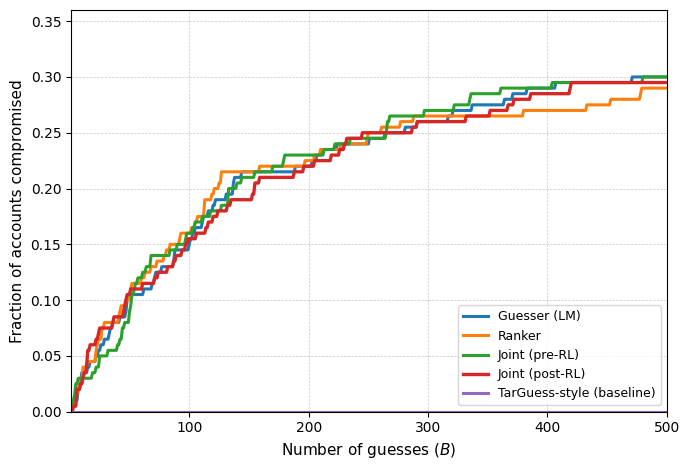

Saved PGC figure files.


In [39]:
# partial guessing curves


# ---- Paths ----
pre_path  = PGC_DIR / "scenario1_all_models_per_user.csv"
post_path = PGC_DIR / "scenario1_postRL_all_models_per_user.csv"
pcfg_path = PGC_DIR / "scenario1_pcfg_per_user.csv"

# ---- Load ----
df_pre  = pd.read_csv(pre_path)
df_post = pd.read_csv(post_path)
df_pcfg = pd.read_csv(pcfg_path)

MAX_RANK = 50000
budgets = np.arange(1, 501)

def pgc_from_ranks(rank_series, budgets, max_rank=50000):
    ranks = rank_series.fillna(max_rank).to_numpy()
    return [(ranks <= b).mean() for b in budgets]

# ---- Figure ----
plt.figure(figsize=(7.0, 4.8))

# ---- Pre-RL curves ----
pre_label_map = {
    "lm": "Guesser (LM)",
    "ranker": "Ranker",
    "preRL": "Joint (pre-RL)",
}

for model_key in ["lm", "ranker", "preRL"]:
    sub = df_pre[df_pre["model"] == model_key].copy()
    if len(sub) == 0:
        print(f"Warning: no rows found for pre model = {model_key}")
        continue
    pgc = pgc_from_ranks(sub["rank"], budgets, MAX_RANK)
    plt.plot(budgets, pgc, linewidth=2.2, label=pre_label_map[model_key])

# ---- Post-RL curve ----
sub = df_post[df_post["model"] == "postRL"].copy()
if len(sub) == 0:
    print("Warning: no rows found for post model = postRL")
else:
    pgc = pgc_from_ranks(sub["rank"], budgets, MAX_RANK)
    plt.plot(budgets, pgc, linewidth=2.4, label="Joint (post-RL)")

# ---- PCFG curve ----
pgc = pgc_from_ranks(df_pcfg["rank"], budgets, MAX_RANK)
plt.plot(budgets, pgc, linewidth=2.2, label="TarGuess-style (baseline)")

# ---- Formatting ----
plt.xlabel("Number of guesses ($B$)", fontsize=11)
plt.ylabel("Fraction of accounts compromised", fontsize=11)
plt.xlim(1, 500)
plt.ylim(0, 0.36)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(frameon=True, fontsize=9, loc="lower right")
plt.tight_layout()

# ---- Save ----
png_path = BASE_DIR / "scenario1_pgc_ccs_clean.png"
pdf_path = BASE_DIR / "scenario1_pgc_ccs_clean.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved PGC figure files.")